# 基于BAO的模型区分——ANN

## 1. 背景介绍

**重子声学振荡（BAO, Baryon Acoustic Oscillations）** 是早期宇宙中声波在重子-光子流体中传播留下的印记。不同的宇宙学模型（如ΛCDM、wCDM等）会产生不同特征的BAO信号。

本notebook展示如何使用**人工神经网络（ANN）**来区分不同宇宙学模型产生的BAO数据。

### 任务类型：分类（Classification）
- 输入：1维BAO观测数据（时间/红移序列）
- 输出：模型类别标签

## 2. 导入必要的库

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 设置随机种子，确保可重复性
torch.manual_seed(42)
np.random.seed(42)

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

使用设备: cuda


## 3. 生成模拟数据

我们模拟3种不同宇宙学模型的BAO数据：
- **模型0**: ΛCDM（标准模型）
- **模型1**: wCDM（暗能量状态方程w≠-1）
- **模型2**: CPL(W0,Wa)

每种模型的数据具有不同的特征模式。

In [2]:
import numpy as np
from astropy.cosmology import w0waCDM
from scipy.constants import c
import matplotlib.pyplot as plt
import pandas as pd
c_kms = c / 1000  # km/s

# ========== 数据加载与模拟类 ==========

class CosmologyData:
    """
    宇宙学数据处理类：支持加载真实数据或生成模拟数据
    """
    def __init__(self, H0=70.0, Om0=0.3, w0=-1.0,wa = 0, Tcmb0=2.725,Ok0 = 0):
        """
        初始化宇宙学参数
        
        参数:
            H0: 哈勃常数 [km/s/Mpc]
            Om0: 物质密度参数
            w0: 暗能量状态方程参数
            Tcmb0: CMB温度 [K]
        """
        self.H0 = H0
        self.Om0 = Om0
        self.w0 = w0
        self.Tcmb0 = Tcmb0
        
        # 创建宇宙学模型
        self.cosmo = w0waCDM(H0=H0, Om0=Om0, Ode0=1-Om0-Ok0, 
                             w0=w0, wa=wa, Tcmb0=Tcmb0)
        
        self.bao_data = None
        self.sn_data = None
    
    # ========== BAO 数据处理 ==========
    
    def load_bao_from_file(self, filepath, columns=(0, 1, 2), skiprows=0):
        """
        从文件加载真实BAO数据
        
        参数:
            filepath: 数据文件路径或URL
            columns: (z列, DV/rd列, error列)
            skiprows: 跳过的行数
        
        返回:
            z, DV_rd, DV_rd_err
        """
        data = np.loadtxt(filepath, usecols=columns, skiprows=skiprows)
        self.bao_data = {
            'z': data[:, 0],
            'DV_rd': data[:, 1],
            'DV_rd_err': data[:, 2],
            'source': 'real'
        }
        return self.bao_data['z'], self.bao_data['DV_rd'], self.bao_data['DV_rd_err']
    
    def load_bao_desi_y1(self):
        """
        加载DESI Year 1 BAO数据（内置）
        """
        # DESI Y1数据点
        desi1_bgs_DVrd =      [0.295, 7.93, 0.15]
        desi1_lrg1_DMrdDHrd = [0.510, 13.62, 0.25, 20.98, 0.61, -0.445]
        desi1_lrg2_DMrdDHrd = [0.706, 16.85, 0.32, 20.08, 0.60, -0.420]
        desi1_lrg3_DMrdDHrd = [0.930, 21.71, 0.28, 17.88, 0.35, -0.389]
        desi1_elg2_DMrdDHrd = [1.317, 27.79, 0.69, 13.82, 0.42, -0.444]
        desi1_qso_DVrd =      [1.491, 26.07, 0.67]
        desi1_lya_DMrdDHrd =  [2.330, 39.71, 0.94, 8.52, 0.17, -0.477]

        def get_DVrd_fromDMDH(x):
            """将DM/rd, DH/rd转换为DV/rd"""
            z, A, dA, B, dB, r = x
            f = (z * (A**2) * B)**(1/3)
            dfdA = (2/3) * A * B * z / (f**2)
            dfdB = f / (3 * B)
            cov_AB = r * dA * dB
            delta_f = np.sqrt((dfdA * dA)**2 + (dfdB * dB)**2 + 2 * dfdA * dfdB * cov_AB)
            return [z, f, delta_f]

        # 将所有数据转换为DV/rd格式
        desi_data_list = []

        # BGS (已经是DV/rd格式)
        desi_data_list.append(desi1_bgs_DVrd)
        # LRG1
        lrg1_DVrd = get_DVrd_fromDMDH(desi1_lrg1_DMrdDHrd)
        desi_data_list.append(lrg1_DVrd)
        # LRG2
        lrg2_DVrd = get_DVrd_fromDMDH(desi1_lrg2_DMrdDHrd)
        desi_data_list.append(lrg2_DVrd)
        # LRG3
        lrg3_DVrd = get_DVrd_fromDMDH(desi1_lrg3_DMrdDHrd)
        desi_data_list.append(lrg3_DVrd)
        # ELG2
        elg2_DVrd = get_DVrd_fromDMDH(desi1_elg2_DMrdDHrd)
        desi_data_list.append(elg2_DVrd)
        # QSO (已经是DV/rd格式)
        desi_data_list.append(desi1_qso_DVrd)
        # LYA
        lya_DVrd = get_DVrd_fromDMDH(desi1_lya_DMrdDHrd)
        desi_data_list.append(lya_DVrd)
        # 转换为numpy矩阵
        desi_matrix = np.array(desi_data_list)

        z         = desi_matrix[:,0]
        DV_rd     = desi_matrix[:,1]
        DV_rd_err = desi_matrix[:,2]
        
        self.bao_data = {
            'z': z,
            'DV_rd': DV_rd,
            'DV_rd_err': DV_rd_err,
            'source': 'DESI_Y1'
        }
        return z, DV_rd, DV_rd_err
    
    def simulate_bao_from_real(self, use_loaded_data=True, rd_fid=147.46, seed=None):
        """
        基于真实数据的红移点和误差，生成模拟BAO观测
        
        参数:
            use_loaded_data: 是否使用已加载的真实数据的红移和误差
            rd_fid: 声学视界尺度
            seed: 随机种子
        
        返回:
            z_mock, DV_rd_mock, DV_rd_err
        """
        if seed is not None:
            np.random.seed(seed)
        
        if use_loaded_data and self.bao_data is not None:
            z = self.bao_data['z']
            DV_rd_err = self.bao_data['DV_rd_err']
        else:
            # 使用默认的DESI Y1红移点和误差
            self.load_bao_desi_y1()
            z = self.bao_data['z']
            DV_rd_err = self.bao_data['DV_rd_err']
        
        # 计算当前宇宙学模型的理论值
        DV_rd_theory = self._compute_DV_rd(z, rd_fid)
        
        # 添加高斯噪声
        DV_rd_mock = np.random.normal(loc=DV_rd_theory, scale=DV_rd_err)
        
        self.bao_data = {
            'z': z,
            'DV_rd': DV_rd_mock,
            'DV_rd_err': DV_rd_err,
            'source': 'simulated'
        }
        
        return z, DV_rd_mock, DV_rd_err
    
    def _compute_DV_rd(self, z, rd_fid=147.46):
        """计算BAO理论值 DV/rd"""
        dHz = c_kms / self.cosmo.H(z).value
        dMz = self.cosmo.luminosity_distance(z).value / (1 + z)
        return ((z * (dMz**2) * dHz)**(1/3)) / rd_fid
    
    # ========== 超新星数据处理 ==========
    
    def load_sn_from_file(self, filepath, columns=(0, 1, 2), skiprows=0):
        """
        从文件加载真实超新星数据
        
        参数:
            filepath: 数据文件路径或URL
            columns: (z列, μ列, error列)
            skiprows: 跳过的行数
        
        返回:
            z, mu, mu_err
        """
        data = pd.read_csv(filepath, delim_whitespace=True)
        z, mu, mu_err = data['zHD'].values, data['MU_SH0ES'].values, data['MU_SH0ES_ERR_DIAG'].values
        self.sn_data = {
            'z': z,
            'mu': mu,
            'mu_err': mu_err,
            'source': 'real'
        }
        return self.sn_data['z'], self.sn_data['mu'], self.sn_data['mu_err']
    
    def load_sn_pantheon_plus(self):
        """
        加载Pantheon+ 超新星数据（从在线源）
        """
        url = 'https://github.com/PantheonPlusSH0ES/DataRelease/raw/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat'
        
        try:
            data = np.loadtxt(url, skiprows=1, usecols=(2, 10, 11))
            # 跳过前111个Cepheid数据点
            z = data[:, 0][111:]
            mu = data[:, 1][111:]
            mu_err = data[:, 2][111:]
            
            self.sn_data = {
                'z': z,
                'mu': mu,
                'mu_err': mu_err,
                'source': 'Pantheon+'
            }
            return z, mu, mu_err
        except Exception as e:
            print(f"无法加载Pantheon+数据: {e}")
            print("使用模拟数据替代...")
            return self.simulate_sn_data()
    
    def simulate_sn_from_real(self, use_loaded_data=True, seed=None):
        """
        基于真实数据的红移点和误差，生成模拟超新星观测
        
        参数:
            use_loaded_data: 是否使用已加载的真实数据的红移和误差
            seed: 随机种子
        
        返回:
            z_mock, mu_mock, mu_err
        """
        if seed is not None:
            np.random.seed(seed)
        
        if use_loaded_data and self.sn_data is not None:
            z = self.sn_data['z']
            mu_err = self.sn_data['mu_err']
        else:
            # 创建默认的红移网格和误差
            z = np.logspace(-2, 0.5, 50)
            mu_err = 0.12 + 0.08 * np.log10(1 + z)
        
        # 计算当前宇宙学模型的理论值
        mu_theory = self.cosmo.distmod(z).value
        
        # 添加高斯噪声
        mu_mock = np.random.normal(loc=mu_theory, scale=mu_err)
        
        self.sn_data = {
            'z': z,
            'mu': mu_mock,
            'mu_err': mu_err,
            'source': 'simulated'
        }
        
        return z, mu_mock, mu_err
    
    def simulate_sn_data(self, n_points=50, z_range=(0.01, 3.0), seed=None):
        """
        生成完全模拟的超新星数据（自定义红移范围和点数）
        """
        if seed is not None:
            np.random.seed(seed)
        
        z = np.logspace(np.log10(z_range[0]), np.log10(z_range[1]), n_points)
        mu_err = 0.12 + 0.08 * np.log10(1 + z)
        mu_theory = self.cosmo.distmod(z).value
        mu_mock = np.random.normal(loc=mu_theory, scale=mu_err)
        
        self.sn_data = {
            'z': z,
            'mu': mu_mock,
            'mu_err': mu_err,
            'source': 'simulated'
        }
        
        return z, mu_mock, mu_err
    
    # ========== 绘图功能 ==========
    
    def plot_data(self, figsize=(14, 5)):
        """绘制BAO和超新星数据"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # 绘制BAO数据
        if self.bao_data is not None:
            z_bao = self.bao_data['z']
            DV_rd = self.bao_data['DV_rd']
            DV_rd_err = self.bao_data['DV_rd_err']
            
            # 绘制数据点
            ax1.errorbar(z_bao, DV_rd / (z_bao**(2/3)), 
                        yerr=DV_rd_err / (z_bao**(2/3)),
                        fmt='o', label=f"Data ({self.bao_data['source']})",
                        markersize=6, capsize=3)
            
            # 绘制理论曲线
            z_theory = np.linspace(z_bao.min(), z_bao.max(), 100)
            DV_rd_theory = self._compute_DV_rd(z_theory)
            ax1.plot(z_theory, DV_rd_theory / (z_theory**(2/3)), 
                    'r-', alpha=0.7, label=f'Theory (H₀={self.H0}, Ωₘ={self.Om0}, w={self.w0})')
            
            ax1.set_xlabel('Redshift z', fontsize=12)
            ax1.set_ylabel(r'$D_V / (r_D z^{2/3})$', fontsize=12)
            ax1.set_title('BAO Observations', fontsize=13, fontweight='bold')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
        
        # 绘制超新星数据
        if self.sn_data is not None:
            z_sn = self.sn_data['z']
            mu = self.sn_data['mu']
            mu_err = self.sn_data['mu_err']
            
            # 数据点
            ax2.errorbar(z_sn, mu, yerr=mu_err,
                        fmt='o', markersize=3, alpha=0.5,
                        label=f"Data ({self.sn_data['source']})", capsize=2)
            
            # 理论曲线
            z_theory = np.logspace(np.log10(z_sn.min()), np.log10(z_sn.max()), 100)
            mu_theory = self.cosmo.distmod(z_theory).value
            ax2.plot(z_theory, mu_theory, 
                    'r-', alpha=0.7, label=f'Theory (H₀={self.H0}, Ωₘ={self.Om0}, w={self.w0})')
            
            ax2.set_xlabel('Redshift z', fontsize=12)
            ax2.set_ylabel('Distance Modulus μ', fontsize=12)
            ax2.set_title('Supernova Observations', fontsize=13, fontweight='bold')
            ax2.set_xscale('log')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig, (ax1, ax2)
    
    def print_summary(self):
        """打印数据摘要"""
        print("=" * 60)
        print("宇宙学数据摘要")
        print("=" * 60)
        print(f"宇宙学参数: H₀={self.H0:.1f} km/s/Mpc, Ωₘ={self.Om0:.3f}, w={self.w0:.2f}")
        print()
        
        if self.bao_data is not None:
            print(f"BAO数据: {len(self.bao_data['z'])} 个数据点")
            print(f"  来源: {self.bao_data['source']}")
            print(f"  红移范围: {self.bao_data['z'].min():.3f} - {self.bao_data['z'].max():.3f}")
            print(f"  误差范围: {self.bao_data['DV_rd_err'].min():.3f} - {self.bao_data['DV_rd_err'].max():.3f}")
        else:
            print("BAO数据: 未加载")
        
        print()
        
        if self.sn_data is not None:
            print(f"超新星数据: {len(self.sn_data['z'])} 个数据点")
            print(f"  来源: {self.sn_data['source']}")
            print(f"  红移范围: {self.sn_data['z'].min():.4f} - {self.sn_data['z'].max():.3f}")
            print(f"  误差范围: {self.sn_data['mu_err'].min():.3f} - {self.sn_data['mu_err'].max():.3f} mag")
        else:
            print("超新星数据: 未加载")
        
        print("=" * 60)




n_samples = 10000 #每类10000个数据
n_classes = 3 #3类
seq_length = 7 #每个数据1维的7个长度的向量


data_list = []
labels_list = []
# ========== 从DESI约束范围采样参数 ==========

# DESI ΛCDM约束 (Table 2 of 2404.03002)
H0_mean, H0_std = 68.52, 0.62
Om0_mean, Om0_std = 0.2956, 0.0048
H0_samples = np.random.normal(H0_mean, H0_std, n_samples)
Om0_samples = np.random.normal(Om0_mean, Om0_std, n_samples)
w0_samples = np.full(n_samples, -1.0)  # ΛCDM固定w=-1

for i in range(n_samples):
    # 用采样的参数创建宇宙学模型
    cosmo = CosmologyData(H0=H0_samples[i], Om0=Om0_samples[i], w0=w0_samples[i])
#     cosmo.load_bao_desi_y1()
    z, DV_rd_mock, _ = cosmo.simulate_bao_from_real(use_loaded_data=True, seed=i)
    data_list.append(DV_rd_mock)# / (z**(2/3)))
    labels_list.append(0)  # ΛCDM标签为0


    
    
# DESI wCDM约束 (Table 2 of 2404.03002)
H0_mean, H0_std = 67.74, 1.06
Om0_mean, Om0_std = 0.3095, 0.0067
w0_mean, w0_std = -0.997, 0.042
H0_samples = np.random.normal(H0_mean, H0_std, n_samples)
Om0_samples = np.random.normal(Om0_mean, Om0_std, n_samples)
w0_samples = np.random.normal(w0_mean, w0_std, n_samples)
for i in range(n_samples):
    # 用采样的参数创建宇宙学模型
    cosmo = CosmologyData(H0=H0_samples[i], Om0=Om0_samples[i], w0=w0_samples[i])
#     cosmo.load_bao_desi_y1()
    z, DV_rd_mock, _ = cosmo.simulate_bao_from_real(use_loaded_data=True, seed=i+n_samples)
    data_list.append(DV_rd_mock)# / (z**(2/3)))
    labels_list.append(1)  # WCDM标签为1


"""
从CPL (Chevallier-Polarski-Linder) 模型采样
w(a) = w0 + wa(1-a)
基于 DESI Y1 + CMB 约束:
"""
H0_mean, H0_std = 68.3, 1.2
Om0_mean, Om0_std = 0.306, 0.010
w0_mean, w0_std = -0.827, 0.063
wa_mean, wa_std = -0.75, 0.29
H0_samples = np.random.normal(H0_mean, H0_std, n_samples)
Om0_samples = np.random.normal(Om0_mean, Om0_std, n_samples)
w0_samples = np.random.normal(w0_mean, w0_std, n_samples)
wa_samples = np.random.normal(wa_mean, wa_std, n_samples)
for i in range(n_samples):
    # 用采样的参数创建宇宙学模型
    cosmo = CosmologyData(H0=H0_samples[i], Om0=Om0_samples[i], w0=w0_samples[i], wa=wa_samples[i])
#     cosmo.load_bao_desi_y1()
    z, DV_rd_mock, _ = cosmo.simulate_bao_from_real(use_loaded_data=True, seed=i+n_samples)
    data_list.append(DV_rd_mock)# / (z**(2/3)))
    labels_list.append(2)  # CPL标签为2

# 合并数据
X = np.vstack(data_list)
y = np.array(labels_list)

print(f'数据形状: X = {X.shape}, y = {y.shape}')
print(f'类别分布: {np.bincount(y)}')

数据形状: X = (30000, 7), y = (30000,)
类别分布: [10000 10000 10000]


In [3]:
cosmo.load_bao_desi_y1()

(array([0.295, 0.51 , 0.706, 0.93 , 1.317, 1.491, 2.33 ]),
 array([ 7.93      , 12.56733789, 15.90704123, 19.86354247, 24.13368485,
        26.07      , 31.51604873]),
 array([0.15      , 0.14769734, 0.19712699, 0.1695468 , 0.36418021,
        0.67      , 0.43800101]))

## 4. 数据可视化

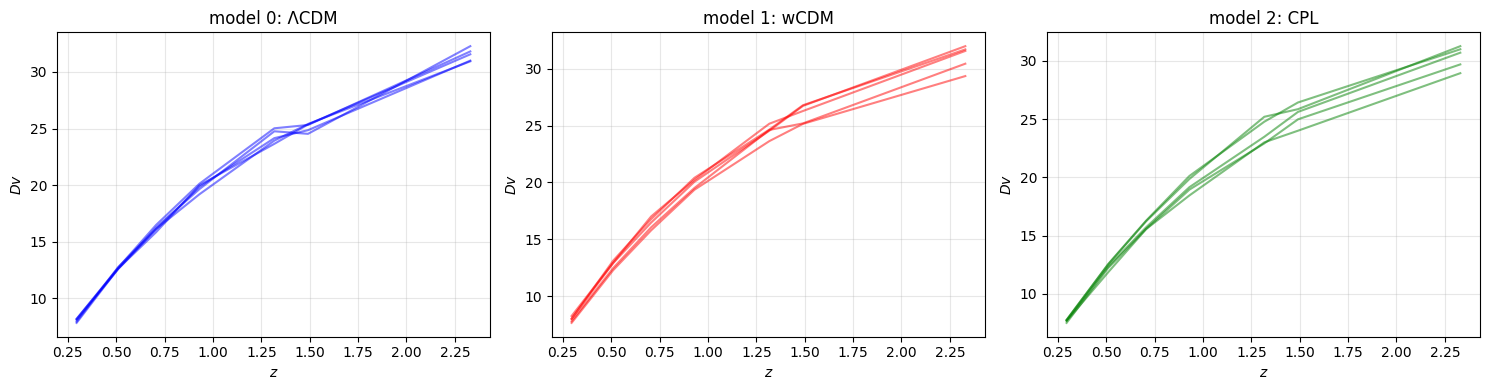

In [4]:
# 可视化不同模型的BAO数据
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_names = ['ΛCDM', 'wCDM', 'CPL']
colors = ['blue', 'red', 'green']

for i in range(3):
    ax = axes[i]
    # 画5条样本曲线
    for j in range(5):
        idx = i * n_samples + j
        ax.plot(z, X[idx], color=colors[i], alpha=0.5)
    ax.set_xlabel('$z$')
    ax.set_ylabel('$Dv$')#('$Dv/(rdz^{2/3})$')
    ax.set_title(f'model {i}: {model_names[i]}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 数据预处理

In [5]:
# 数据标准化
X_mean = X.mean()
X_std = X.std()
X_normalized = (X - X_mean) / X_std

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)

print(f'训练集大小: {X_train.shape[0]}')
print(f'测试集大小: {X_test.shape[0]}')

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# 创建数据加载器
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

训练集大小: 24000
测试集大小: 6000


## 6. 定义ANN模型

我们使用一个简单的全连接神经网络（MLP）进行分类：
- 输入层：接收1D序列数据
- 隐藏层：多层全连接层 + ReLU激活
- 输出层：Softmax分类

In [6]:
class ANNClassifier(nn.Module):
    """
    用于BAO模型区分的人工神经网络
    
    结构：
    输入(seq_length) -> FC(16) -> ReLU -> Dropout
                     -> FC(32)  -> ReLU -> Dropout
                     -> FC(16)  -> ReLU 
                     -> FC(n_classes) -> Softmax
    """
    def __init__(self, input_size, n_classes, dropout_rate=0.3):
        super(ANNClassifier, self).__init__()
        
        self.network = nn.Sequential(
            # 第一层
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # 第二层
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # 第三层
            nn.Linear(32, 16),
            nn.ReLU(),
            
            # 输出层
            nn.Linear(16, n_classes)
        )
    
    def forward(self, x):
        """
        前向传播
        
        参数:
            x: 输入数据, shape = (batch_size, seq_length)
        返回:
            logits: 未归一化的类别分数, shape = (batch_size, n_classes)
        """
        return self.network(x)

# 实例化模型
model = ANNClassifier(input_size=seq_length, n_classes=n_classes,dropout_rate=0.0)
model = model.to(device)

# 打印模型结构
print(model)
print(f'\n模型参数总数: {sum(p.numel() for p in model.parameters()):,}')

ANNClassifier(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=16, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=3, bias=True)
  )
)

模型参数总数: 1,251


## 7. 定义损失函数和优化器

In [7]:
# 交叉熵损失函数（适用于多分类问题）
criterion = nn.CrossEntropyLoss()

# Adam优化器
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 学习率调度器（可选）
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

## 8. 训练模型

In [8]:
# 训练参数
n_epochs = 100

# 记录训练过程
train_losses = []
test_losses = []
train_accs = []
test_accs = []

print('开始训练...')
print('='*60)

for epoch in range(n_epochs):
    # ==================== 训练阶段 ====================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)  # 内部会自动做 softmax
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 统计
        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
    
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # ==================== 验证阶段 ====================
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)  # 内部会自动做 softmax
            
            test_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            test_total += batch_y.size(0)
            test_correct += (predicted == batch_y).sum().item()
    
    test_loss = test_loss / test_total
    test_acc = test_correct / test_total
    
    # 更新学习率
    scheduler.step()
    
    # 记录
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    # 打印进度
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{n_epochs}] | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}')

print('='*60)
print('训练完成!')

开始训练...
Epoch [ 10/100] | Train Loss: 0.9915 | Train Acc: 0.4851 | Test Loss: 0.9867 | Test Acc: 0.4882
Epoch [ 20/100] | Train Loss: 0.9685 | Train Acc: 0.5083 | Test Loss: 0.9681 | Test Acc: 0.5097
Epoch [ 30/100] | Train Loss: 0.9178 | Train Acc: 0.5468 | Test Loss: 0.9127 | Test Acc: 0.5538
Epoch [ 40/100] | Train Loss: 0.8985 | Train Acc: 0.5613 | Test Loss: 0.8986 | Test Acc: 0.5595
Epoch [ 50/100] | Train Loss: 0.8903 | Train Acc: 0.5667 | Test Loss: 0.8942 | Test Acc: 0.5610
Epoch [ 60/100] | Train Loss: 0.8869 | Train Acc: 0.5663 | Test Loss: 0.8992 | Test Acc: 0.5553
Epoch [ 70/100] | Train Loss: 0.8837 | Train Acc: 0.5717 | Test Loss: 0.8883 | Test Acc: 0.5637
Epoch [ 80/100] | Train Loss: 0.8828 | Train Acc: 0.5713 | Test Loss: 0.8886 | Test Acc: 0.5675
Epoch [ 90/100] | Train Loss: 0.8814 | Train Acc: 0.5718 | Test Loss: 0.8867 | Test Acc: 0.5692
Epoch [100/100] | Train Loss: 0.8800 | Train Acc: 0.5731 | Test Loss: 0.8858 | Test Acc: 0.5685
训练完成!


## 9. 可视化训练过程

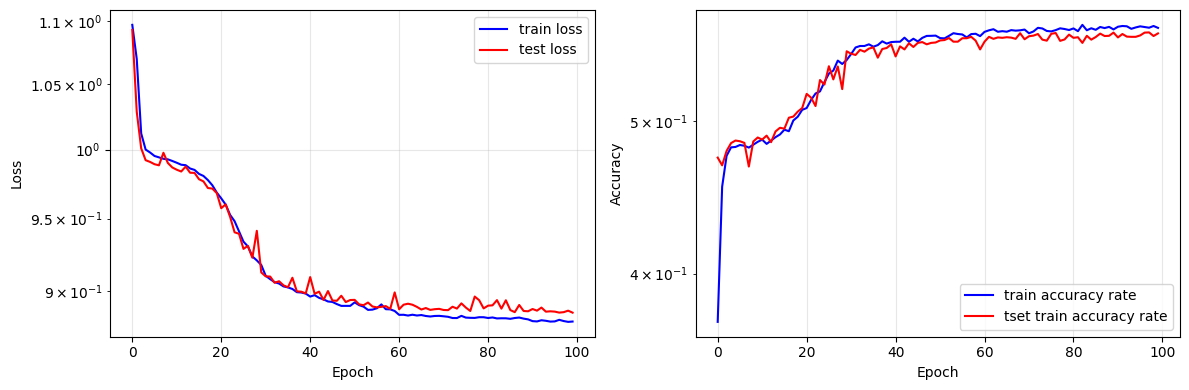

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(train_losses, label='train loss', color='blue')
axes[0].plot(test_losses, label='test loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(train_accs, label='train accuracy rate', color='blue')
axes[1].plot(test_accs, label='tset train accuracy rate', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. 模型评估

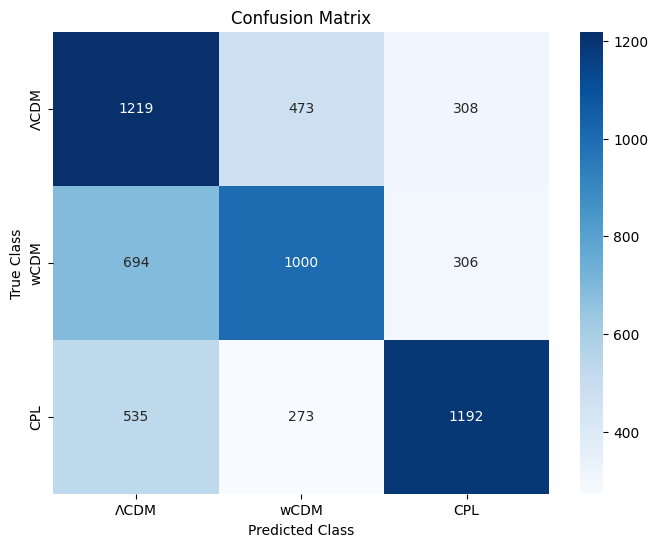


Classification Report:
              precision    recall  f1-score   support

        ΛCDM       0.50      0.61      0.55      2000
        wCDM       0.57      0.50      0.53      2000
         CPL       0.66      0.60      0.63      2000

    accuracy                           0.57      6000
   macro avg       0.58      0.57      0.57      6000
weighted avg       0.58      0.57      0.57      6000



In [10]:
# 在测试集上评估
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 混淆矩阵
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ΛCDM', 'wCDM', 'CPL'],
            yticklabels=['ΛCDM', 'wCDM', 'CPL'])
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()

# 分类报告
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, 
                          target_names=['ΛCDM', 'wCDM', 'CPL']))

## 11. 使用模型进行预测

Prediction Result:
  Predicted class: 0 (ΛCDM)
  Class probabilities: 
    ΛCDM: 0.4587
    wCDM: 0.1439
    CPL: 0.3974


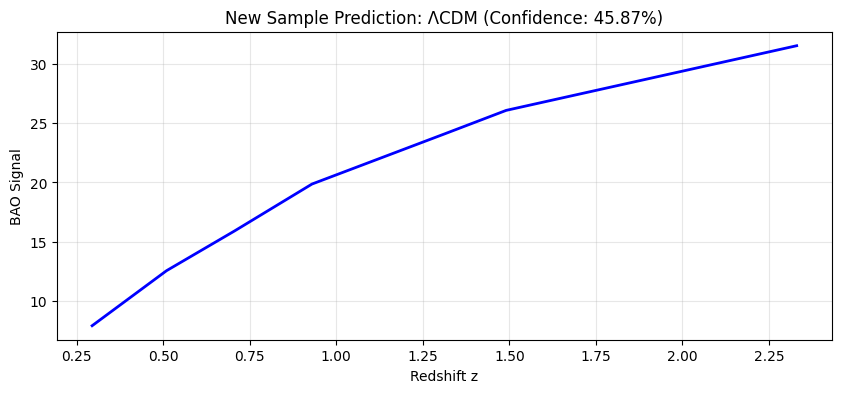

In [11]:
# 生成一个新样本进行预测
#https://arxiv.org/abs/2510.09074——几乎无法区分，甚至弱弱偏向于LCDM
_, new_sample, _ = cosmo.load_bao_desi_y1()
new_sample = new_sample #/ (z**(2/3))
new_sample = new_sample.reshape(1,-1)
new_sample_normalized = (new_sample - X_mean) / X_std
new_sample_tensor = torch.FloatTensor(new_sample_normalized).to(device)

# 预测
model.eval()
with torch.no_grad():
    output = model(new_sample_tensor)
    probabilities = torch.softmax(output, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()

print('Prediction Result:')
print(f'  Predicted class: {predicted_class} ({model_names[predicted_class]})')
print(f'  Class probabilities: ')
for i, name in enumerate(model_names):
    print(f'    {name}: {probabilities[0, i].item():.4f}')

# 可视化预测样本
plt.figure(figsize=(10, 4))
plt.plot(z, new_sample[0], 'b-', linewidth=2)
plt.xlabel('Redshift z')
plt.ylabel('BAO Signal')
plt.title(f'New Sample Prediction: {model_names[predicted_class]} '
          f'(Confidence: {probabilities[0, predicted_class].item():.2%})')
plt.grid(True, alpha=0.3)
plt.show()

## 12. 保存模型

In [12]:
# 保存模型
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'X_mean': X_mean,
    'X_std': X_std,
    'model_names': model_names
}, 'bao_ann_classifier.pth')

print('模型已保存到 bao_ann_classifier.pth')

模型已保存到 bao_ann_classifier.pth


## 13. 总结

### 本notebook要点:

1. **数据准备**: 将1D时间序列数据标准化后输入网络
2. **ANN结构**: 使用全连接层 + ReLU激活 + Dropout正则化
3. **损失函数**: 多分类问题使用交叉熵损失 (CrossEntropyLoss)
4. **优化器**: Adam优化器 + 学习率调度
5. **评估指标**: 准确率、混淆矩阵、分类报告

### ANN的优缺点:

**优点:**
- 结构简单，易于理解和实现
- 训练速度快
- 对于全局特征提取效果好

**缺点:**
- 没有考虑序列的时序特性
- 参数量随输入维度增加而快速增长
- 对局部特征的捕捉能力有限